How many late days are you using for this assignment? 0

In [72]:
# Imports and pip installations (if needed)
import pandas as pd

# Part 1: Load the dataset

In [73]:
# Load the given datasets

numerical_data = pd.read_csv('chronic_kidney_disease_numerical.csv')
categorial_data = pd.read_csv('chronic_kidney_disease_categorical.csv')
# Print the data
print(numerical_data)
print(categorial_data)

     unique_id   age     bp    bgr     bu   sc    sod  pot  hemo   pcv  \
0       203694  38.0   80.0   99.0   19.0  0.5  147.0  3.5  13.6  44.0   
1       938027  43.0   60.0  108.0   25.0  1.0  144.0  5.0  17.8  43.0   
2       421471  37.0   60.0  111.0   35.0  0.8  135.0  4.1  16.2  50.0   
3       764115  70.0   90.0  144.0  125.0  4.0  136.0  4.6  12.0  37.0   
4       240975  47.0   80.0   95.0   35.0  0.9  140.0  4.1   NaN   NaN   
..         ...   ...    ...    ...    ...  ...    ...  ...   ...   ...   
415     522912  56.0   80.0  165.0   55.0  1.8    NaN  NaN  13.5  40.0   
416     475200  64.0  100.0  163.0   54.0  7.2  140.0  4.6   7.9  26.0   
417     168242  48.0   60.0  112.0   44.0  1.2  142.0  4.9  14.5  44.0   
418     474407  21.0   90.0  107.0   40.0  1.7  125.0  3.5   8.3  23.0   
419     926033  50.0   70.0  230.0   50.0  2.2    NaN  NaN  12.0  41.0   

        wbcc  rbcc  
0     7300.0   6.4  
1     7200.0   5.5  
2     5500.0   5.7  
3     8200.0   4.5  
4     

# Part 2: Analyze the Dataset

Refer to this: https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease

Explain what the each data is in your own words. What are the features and labels? Are the features in the given datasets : categorical, numerical or both? Give 3 examples of categorical and numerical columns each (if they exist)

Answer: They are both categorical and numerical. The features and labels represent different aspects that have to do with chronic kidney disease. Three examples of numerical features are age, pcv, and hemo. Three categorial examples are dm, appet, htn.

# Part 3: Data Preprocessing

A fundamental skill in Machine Learning is mastering the art of data cleaning and preprocessing. In this assignment, you will learn and apply essential data cleaning techniques to transform a raw dataset into a clean, ready-to-use form which you can use for regression or classification tasks. By the end of this assignment, you'll have a fully clean dataset and a solid foundation in preparing data for various machine learning models.

## Part 3.1 : Drop Duplicate rows

Let's start by checking if the given datasets have any duplicate rows (same Unique Id). Use pandas to identify and remove these duplicate rows from the given dataset

In [74]:
# For the numerical dataset, check if there are duplicate rows in the dataset. If yes, print total number of duplicate rows

print(len(numerical_data) - numerical_data['unique_id'].nunique())

# Drop these duplicate rows
numerical_data_cleaned = numerical_data.drop_duplicates(subset='unique_id', keep='first')

# Repeat the same for categorical dataset. Print the duplicate rows and drop them
print(len(categorial_data) - categorial_data['unique_id'].nunique())
categorial_data_cleaned = categorial_data.drop_duplicates(subset='unique_id', keep='first')


30
30


## Part 3.2: Combine two differents datasets

A good skill to have is to know how to combine 2 different datasets.

Are all the unique ids are present in both datasets? Why do you think so? If not, what do the rows that are missing from one of the datasets look like in the combined table?

Answer: No not all unique ids are present. numerical_data_cleaned has all ids in categorial_data_cleaned, but the inverse is not true. Specifically, numerical_data_cleaned does not contain ids 208034, 240430, 488947, 325238, 254775, 292312, 298297, 663387, 948317, and 266335. The rows look like this:

     unique_id  age  bp  bgr  bu  sc  sod  pot  hemo  pcv  ...         pcc  \
47      208034  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...  notpresent   
58      240430  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...         NaN   
64      254775  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...  notpresent   
69      266335  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...  notpresent   
80      292312  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...  notpresent   
83      298297  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...  notpresent   
97      325238  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...  notpresent   
173     488947  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...  notpresent   
261     663387  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...  notpresent   
376     948317  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...  notpresent   

             ba  htn   dm  cad appet   pe  ane  Target      _merge  
47   notpresent  yes  yes  yes  good  yes   no     ckd  right_only  
58          NaN   no   no   no  good   no   no  notckd  right_only  
64   notpresent  yes  yes  yes  good   no  yes     ckd  right_only  
69   notpresent   no   no   no  good   no   no  notckd  right_only  
80   notpresent   no   no   no  good   no   no  notckd  right_only  
83   notpresent   no   no   no  good   no   no  notckd  right_only  
97   notpresent  yes  yes   no  poor   no  yes   ckd\t  right_only  
173  notpresent   no   no   no  good   no   no     ckd  right_only  
261  notpresent   no   no   no  poor   no  yes     ckd  right_only  
376  notpresent   no   no   no  good   no   no  notckd  right_only  

In [75]:

combined_dataset = pd.merge(numerical_data_cleaned, 
                             categorial_data_cleaned, 
                             on='unique_id' 
                            )

combined_dataset_outer = pd.merge(numerical_data_cleaned, 
                                  categorial_data_cleaned, 
                                  on='unique_id', 
                                  how='outer', 
                                  indicator=True)

# Filter the rows that are missing in either dataset
missing_rows = combined_dataset_outer[combined_dataset_outer['_merge'] != 'both']

# Print the missing rows
print(missing_rows)
#Print the combined dataset
print(combined_dataset)

     unique_id  age  bp  bgr  bu  sc  sod  pot  hemo  pcv  ...         pcc  \
47      208034  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...  notpresent   
58      240430  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...         NaN   
64      254775  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...  notpresent   
69      266335  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...  notpresent   
80      292312  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...  notpresent   
83      298297  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...  notpresent   
97      325238  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...  notpresent   
173     488947  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...  notpresent   
261     663387  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...  notpresent   
376     948317  NaN NaN  NaN NaN NaN  NaN  NaN   NaN  NaN  ...  notpresent   

             ba  htn   dm  cad appet   pe  ane  Target      _merge  
47   notpresent  yes  yes  yes  good  yes   no     ckd  right_only  
58 

## Part 3.3: Rows with Missing values

Removing missing values from a dataset is important for classification because it ensures the model is trained on complete and accurate data, leading to better performance and reliable predictions. Incomplete data can introduce bias and errors, negatively impacting the model's effectiveness.

In [76]:
# Calculate the percentage of rows that contain atleast one missing value
missing_values = combined_dataset.isnull().any(axis=1).sum()
# Print %
print((missing_values/len(combined_dataset))*100)
# Drop these rows from the dataset
combined_dataset_cleaned = combined_dataset.dropna().reset_index(drop=True)
# Print the Dataset
print(combined_dataset_cleaned)

60.76923076923077
     unique_id   age     bp    bgr    bu   sc    sod  pot  hemo   pcv  ...  \
0       203694  38.0   80.0   99.0  19.0  0.5  147.0  3.5  13.6  44.0  ...   
1       938027  43.0   60.0  108.0  25.0  1.0  144.0  5.0  17.8  43.0  ...   
2       421471  37.0   60.0  111.0  35.0  0.8  135.0  4.1  16.2  50.0  ...   
3       109053  64.0   60.0  106.0  27.0  0.7  150.0  3.3  14.4  42.0  ...   
4       349892  59.0   70.0  424.0  55.0  1.7  138.0  4.5  12.6  37.0  ...   
..         ...   ...    ...    ...   ...  ...    ...  ...   ...   ...  ...   
148     486397  20.0   70.0  123.0  44.0  1.0  135.0  3.8  14.6  44.0  ...   
149     462892  36.0   80.0   85.0  16.0  1.1  142.0  4.1  15.6  44.0  ...   
150     475200  64.0  100.0  163.0  54.0  7.2  140.0  4.6   7.9  26.0  ...   
151     168242  48.0   60.0  112.0  44.0  1.2  142.0  4.9  14.5  44.0  ...   
152     474407  21.0   90.0  107.0  40.0  1.7  125.0  3.5   8.3  23.0  ...   

           pc         pcc          ba  htn   

## Part 3.4: Sort the dataset according to the Labels

In [77]:
# Sort the dataset according to the values in 'Target' column. Make sure reset the indices after sorting
combined_dataset_cleaned_sorted = combined_dataset_cleaned.sort_values('Target').reset_index(drop=True)
# Print the dataset
print(combined_dataset_cleaned_sorted)

     unique_id   age     bp    bgr     bu   sc    sod  pot  hemo   pcv  ...  \
0       474407  21.0   90.0  107.0   40.0  1.7  125.0  3.5   8.3  23.0  ...   
1       137148  73.0  100.0  295.0   90.0  5.6  140.0  2.9   9.2  30.0  ...   
2       484175  53.0   90.0   70.0  107.0  7.2  114.0  3.7   9.5  29.0  ...   
3       343710  61.0   80.0  173.0  148.0  3.9  135.0  5.2   7.7  24.0  ...   
4       532520  60.0   90.0  105.0   53.0  2.3  136.0  5.2  11.1  33.0  ...   
..         ...   ...    ...    ...    ...  ...    ...  ...   ...   ...  ...   
148     647552  61.0   70.0  120.0   29.0  0.7  137.0  3.5  17.4  52.0  ...   
149     125587  37.0   60.0  109.0   47.0  1.1  141.0  4.9  15.0  48.0  ...   
150     614376  57.0   80.0  119.0   17.0  1.2  135.0  4.7  15.4  42.0  ...   
151     853426  41.0   70.0  125.0   38.0  0.6  140.0  5.0  16.8  41.0  ...   
152     572140  55.0   80.0  104.0   28.0  0.9  142.0  4.8  17.3  52.0  ...   

           pc         pcc          ba  htn   dm  ca

## Part 3.5: Encoding Categorical data

In this step, we identify and process the categorical columns in the sorted dataset. We map each unique value in these columns to separate "dummy" columns.

For example, the column 'rbc' will be transformed into two columns 'rbc_normal' and 'rbc_abnormal'. If a row's value in 'rbc' is 'normal', the 'rbc_normal' column will be set to 1 and 'rbc_abnormal' will be set to 0.


**Note: Find a correct pandas function to do this **

In [78]:
# Write code here
categorical_columns = ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'Target']
combined_dataset_encoded = pd.get_dummies(combined_dataset_cleaned_sorted, columns=categorical_columns, drop_first=False)
# Print the dataset
print(combined_dataset_encoded)

     unique_id   age     bp    bgr     bu   sc    sod  pot  hemo   pcv  ...  \
0       474407  21.0   90.0  107.0   40.0  1.7  125.0  3.5   8.3  23.0  ...   
1       137148  73.0  100.0  295.0   90.0  5.6  140.0  2.9   9.2  30.0  ...   
2       484175  53.0   90.0   70.0  107.0  7.2  114.0  3.7   9.5  29.0  ...   
3       343710  61.0   80.0  173.0  148.0  3.9  135.0  5.2   7.7  24.0  ...   
4       532520  60.0   90.0  105.0   53.0  2.3  136.0  5.2  11.1  33.0  ...   
..         ...   ...    ...    ...    ...  ...    ...  ...   ...   ...  ...   
148     647552  61.0   70.0  120.0   29.0  0.7  137.0  3.5  17.4  52.0  ...   
149     125587  37.0   60.0  109.0   47.0  1.1  141.0  4.9  15.0  48.0  ...   
150     614376  57.0   80.0  119.0   17.0  1.2  135.0  4.7  15.4  42.0  ...   
151     853426  41.0   70.0  125.0   38.0  0.6  140.0  5.0  16.8  41.0  ...   
152     572140  55.0   80.0  104.0   28.0  0.9  142.0  4.8  17.3  52.0  ...   

     cad_no  cad_yes  appet_good  appet_poor  pe_no

In the example we went through above, another solution is to have a single column for the binary variable. In the downstream modeling would this be equivalent? What effect would this have if the categorical variable could take more than 2 values? For example, let's say we have a categorical feature that is "type of condiment" that can take 5 separate values and we are trying to predict the rating of a particular sandwich.

Answer: A simple binary True, False approach would not work. Since there could be more than two options, they would not all be able to be represented. I see two solutions to this. The first would be to expand our current approach and add n columns for every possible value. Another would be to expand from true false, having 0 to n-1 integers to represent every option in a single column. For example, a condiment column might have values 0,1,2,3,4 representing ketchup, mustard, relish, mayo, and hot sauce, keeping our columns clean.

## Part 3.6 : Remove Outliers from Numerical Columns

Outliers can disproportionately influence the fit of a regression model, potentially leading to a model that does not generalize well therefore it is important that we remove outliers from the numerical columns of the dataset.

For this dataset, we define an outlier to be 3 times the standard deviation from the mean. Drop these outliers from the dataset

In [79]:
# Remove outliers

numerical_columns = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']

combined_dataset_no_outliers = combined_dataset_encoded.copy()

for column in numerical_columns:
    mean = combined_dataset_no_outliers[column].mean()
    std = combined_dataset_no_outliers[column].std()

    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std

    combined_dataset_no_outliers = combined_dataset_no_outliers[(combined_dataset_no_outliers[column] > lower_bound) & (combined_dataset_no_outliers[column] < upper_bound)]

# Print the dataset
combined_dataset_no_outliers = combined_dataset_no_outliers.reset_index(drop=True)
print(combined_dataset_no_outliers)

     unique_id   age     bp    bgr     bu   sc    sod  pot  hemo   pcv  ...  \
0       474407  21.0   90.0  107.0   40.0  1.7  125.0  3.5   8.3  23.0  ...   
1       137148  73.0  100.0  295.0   90.0  5.6  140.0  2.9   9.2  30.0  ...   
2       343710  61.0   80.0  173.0  148.0  3.9  135.0  5.2   7.7  24.0  ...   
3       532520  60.0   90.0  105.0   53.0  2.3  136.0  5.2  11.1  33.0  ...   
4       546225  46.0   60.0  163.0   92.0  3.3  141.0  4.0   9.8  28.0  ...   
..         ...   ...    ...    ...    ...  ...    ...  ...   ...   ...  ...   
128     647552  61.0   70.0  120.0   29.0  0.7  137.0  3.5  17.4  52.0  ...   
129     125587  37.0   60.0  109.0   47.0  1.1  141.0  4.9  15.0  48.0  ...   
130     614376  57.0   80.0  119.0   17.0  1.2  135.0  4.7  15.4  42.0  ...   
131     853426  41.0   70.0  125.0   38.0  0.6  140.0  5.0  16.8  41.0  ...   
132     572140  55.0   80.0  104.0   28.0  0.9  142.0  4.8  17.3  52.0  ...   

     cad_no  cad_yes  appet_good  appet_poor  pe_no

## Part 3.7 : Normalize the Numerical Columns

Normalizing numerical attributes ensures that all features contribute equally to the model by scaling them to a consistent range, which improves model performance and convergence. It prevents features with larger scales from disproportionately influencing the model's learning process.

In [80]:
from sklearn.preprocessing import MinMaxScaler

scaler =  MinMaxScaler()
normalized_numerical = combined_dataset_no_outliers.copy()
normalized_numerical[numerical_columns] = scaler.fit_transform(normalized_numerical[numerical_columns])
# Print the dataset
print(normalized_numerical)

     unique_id       age    bp       bgr        bu        sc       sod  \
0       474407  0.202703  0.75  0.158798  0.196078  0.160494  0.166667   
1       137148  0.905405  1.00  0.965665  0.522876  0.641975  0.666667   
2       343710  0.743243  0.50  0.442060  0.901961  0.432099  0.500000   
3       532520  0.729730  0.75  0.150215  0.281046  0.234568  0.533333   
4       546225  0.540541  0.00  0.399142  0.535948  0.358025  0.700000   
..         ...       ...   ...       ...       ...       ...       ...   
128     647552  0.743243  0.25  0.214592  0.124183  0.037037  0.566667   
129     125587  0.418919  0.00  0.167382  0.241830  0.086420  0.700000   
130     614376  0.689189  0.50  0.210300  0.045752  0.098765  0.500000   
131     853426  0.472973  0.25  0.236052  0.183007  0.024691  0.666667   
132     572140  0.662162  0.50  0.145923  0.117647  0.061728  0.733333   

          pot      hemo       pcv  ...  cad_no  cad_yes  appet_good  \
0    0.206897  0.059406  0.000000  ...  

## Part 3.8: Remove Unnecessary columns

Are there any columns in this dataset which are not appropriate for modeling and predictions? Which column(s)? Justify their exclusion and remove them

Answer: The first obvious column that can be excluded are unique id. Unique id provides no insight to the model about the actual data so it can be removed. Past that, we can exclude one of two columns that have high similarity, as their data will be for the most part colinear. By plotting their corrolation, we can see that bu and sc are 77% similar, and pcv and hemo are 75% similar. It can be relatively safe to remove one of each.

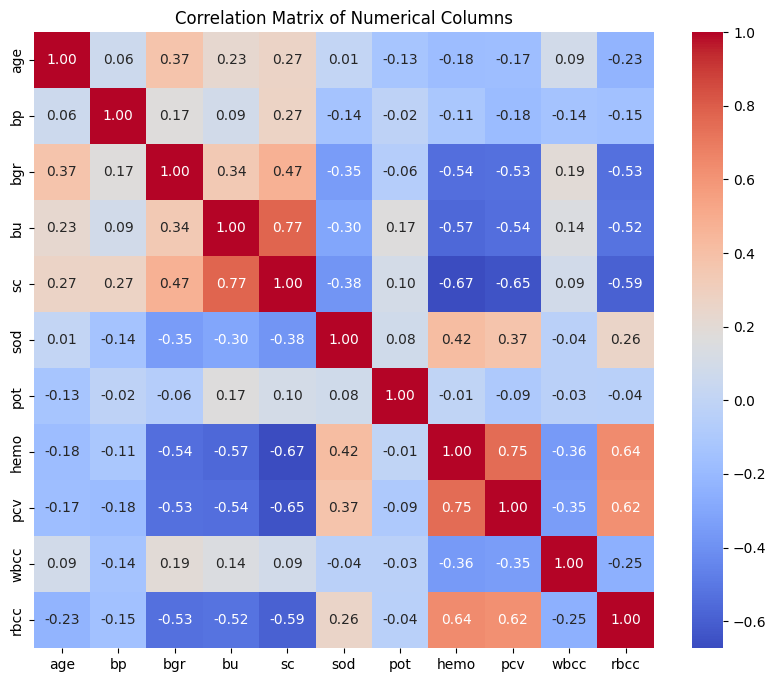

          age    bp       bgr        sc       sod       pot      hemo  \
0    0.202703  0.75  0.158798  0.160494  0.166667  0.206897  0.059406   
1    0.905405  1.00  0.965665  0.641975  0.666667  0.000000  0.148515   
2    0.743243  0.50  0.442060  0.432099  0.500000  0.793103  0.000000   
3    0.729730  0.75  0.150215  0.234568  0.533333  0.793103  0.336634   
4    0.540541  0.00  0.399142  0.358025  0.700000  0.379310  0.207921   
..        ...   ...       ...       ...       ...       ...       ...   
128  0.743243  0.25  0.214592  0.037037  0.566667  0.206897  0.960396   
129  0.418919  0.00  0.167382  0.086420  0.700000  0.689655  0.722772   
130  0.689189  0.50  0.210300  0.098765  0.500000  0.620690  0.762376   
131  0.472973  0.25  0.236052  0.024691  0.666667  0.724138  0.900990   
132  0.662162  0.50  0.145923  0.061728  0.733333  0.655172  0.950495   

         wbcc      rbcc   al  ...  cad_no  cad_yes  appet_good  appet_poor  \
0    0.653226  0.257143  4.0  ...    True    

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = normalized_numerical[numerical_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Columns')
plt.show()

remove_columns = ['unique_id', 'pcv', 'bu']
normalized_numerical = normalized_numerical.drop(columns=remove_columns, axis=1)
print(normalized_numerical)

## Part 3.9: Export the Cleaned Data

Now that you've completed these cleaning steps you should have a pandas dataframe which is much cleaner and ready for modeling. Our final step is to save our work. Export the DataFrame to a two new formats: csv and json.

In [82]:
# Export the dataframe to a new csv file
normalized_numerical.to_csv("cleaned_kidney_disease.csv", index=False)
# Export the dataframe to a new json file
normalized_numerical.to_json("cleaned_kidney_disease.json", orient='records')

# Part 4: Data conversions with Large Language Models

One powerful use case of ChatGPT (and other generative language models) is cleaning and transforming data. In some cases, these models can directly manipulate loosely structured data that you provide to them into a standard format. In the other cases, you can often prompt the model to create a conversion or extraction script for you in python or Pandas and then run it on your own. 

In this part of the assignment you will prompt 383GPT to explore these capabilities.

## Part 4.1 GPT Data Manipulation

Take the cleaned dataset that you created in part three and output the top 15 rows of that dataset. Then copy the terminal output, open 383gpt and ask it to convert that output to a markdown table. Paste that markdown table in the cell bellow

Paste here: 
# Chronic Kidney Disease Dataset

This dataset contains various medical parameters and target classifications for chronic kidney disease (CKD).

## Data Sample

| age | bp | bgr | sc | sod | pot | hemo | wbcc | rbcc | al | su | rbc_abnormal | rbc_normal | pc_abnormal | pc_normal | pcc_notpresent | pcc_present | ba_notpresent | ba_present | htn_no | htn_yes | dm_no | dm_yes | cad_no | cad_yes | appet_good | appet_poor | pe_no | pe_yes | ane_no | ane_yes | Target_ckd | Target_notckd |
|------|------|------|------|------|------|------|------|------|------|------|-------------|-----------|------------|----------|---------------|------------|--------------|-----------|--------|---------|-------|--------|--------|---------|------------|-----------|-------|--------|--------|---------|------------|--------------|
| 0.203 | 0.750 | 0.159 | 0.160 | 0.167 | 0.207 | 0.059 | 0.653 | 0.257 | 4.0 | 0.0 | False | True | True | False | False | True | False | True | True | False | True | False | True | False | True | False | True | False | False | True | True | False |
| 0.905 | 1.000 | 0.966 | 0.642 | 0.667 | 0.000 | 0.149 | 0.218 | 0.057 | 3.0 | 2.0 | True | False | True | False | False | True | True | False | False | True | False | True | False | True | False | True | True | False | True | False | True | False |
| 0.743 | 0.500 | 0.442 | 0.432 | 0.500 | 0.793 | 0.000 | 0.395 | 0.057 | 2.0 | 0.0 | True | False | True | False | True | False | True | False | False | True | False | True | False | True | False | True | False | True | False | True | True | False |
| 0.730 | 0.750 | 0.150 | 0.235 | 0.533 | 0.793 | 0.337 | 0.500 | 0.314 | 2.0 | 0.0 | True | False | False | True | True | False | True | False | True | False | True | False | True | False | True | False | True | False | True | False | True | False |
| 0.541 | 0.000 | 0.399 | 0.358 | 0.700 | 0.379 | 0.208 | 0.831 | 0.057 | 1.0 | 0.0 | False | True | False | True | True | False | True | False | False | True | False | True | True | False | True | False | True | False | True | False | True | False |
| 0.676 | 0.750 | 0.253 | 0.778 | 0.367 | 0.655 | 0.139 | 0.169 | 0.114 | 2.0 | 0.0 | True | False | True | False | True | False | True | False | False | True | True | False | True | False | True | False | True | False | True | False | True | False |
| 0.716 | 0.500 | 1.000 | 0.111 | 0.067 | 0.207 | 0.267 | 0.532 | 0.371 | 1.0 | 0.0 | True | False | False | True | True | False | True | False | True | False | False | True | True | False | False | True | True | False | True | False | True | False |
| 0.730 | 0.000 | 0.936 | 0.160 | 0.333 | 0.034 | 0.020 | 0.879 | 0.000 | 3.0 | 1.0 | False | True | True | False | False | True | True | False | False | True | True | False | True | False | False | True | True | False | False | True | True | False |
| 0.000 | 0.000 | 0.103 | 0.074 | 0.500 | 0.690 | 0.218 | 1.000 | 0.514 | 4.0 | 0.0 | True | False | True | False | True | False | False | True | True | False | True | False | True | False | False | True | True | False | True | False | True | False |
| 0.878 | 0.000 | 0.206 | 0.605 | 0.533 | 0.690 | 0.366 | 0.879 | 0.371 | 4.0 | 0.0 | False | True | False | True | True | False | True | False | False | True | False | True | True | False | False | True | False | True | True | False | True | False |
| 0.851 | 0.250 | 0.618 | 0.728 | 0.000 | 0.345 | 0.168 | 0.581 | 0.086 | 4.0 | 3.0 | False | True | True | False | False | True | False | True | False | True | False | True | False | True | True | False | False | True | False | True | True | False |
| 0.878 | 0.250 | 0.639 | 0.395 | 0.433 | 0.517 | 0.267 | 0.105 | 0.171 | 3.0 | 0.0 | False | True | True | False | False | True | False | True | False | True | False | True | False | True | True | False | True | False | True | False | True | False |
| 0.784 | 0.000 | 0.725 | 0.481 | 0.567 | 0.862 | 0.178 | 0.258 | 0.114 | 4.0 | 1.0 | True | False | True | False | True | False | False | True | False | True | False | True | True | False | False | True | False | True | True | False | True | False |
| 0.662 | 0.500 | 0.618 | 0.432 | 0.567 | 0.690 | 0.317 | 0.250 | 0.200 | 3.0 | 1.0 | False | True | True | False | False | True | False | True | False | True | False | True | True | False | True | False | False | True | True | False | True | False |

## Feature Descriptions

### Numerical Features
- **age**: Normalized age of the patient
- **bp**: Normalized blood pressure
- **bgr**: Normalized blood glucose random
- **sc**: Normalized serum creatinine
- **sod**: Normalized sodium
- **pot**: Normalized potassium
- **hemo**: Normalized hemoglobin
- **wbcc**: Normalized white blood cell count
- **rbcc**: Normalized red blood cell count
- **al**: Albumin level (0-5)
- **su**: Sugar level (0-5)

### Categorical Features (Boolean)
- **rbc_abnormal/rbc_normal**: Red blood cells condition
- **pc_abnormal/pc_normal**: Pus cell condition
- **pcc_notpresent/pcc_present**: Pus cell clumps presence
- **ba_notpresent/ba_present**: Bacteria presence
- **htn_no/htn_yes**: Hypertension status
- **dm_no/dm_yes**: Diabetes mellitus status
- **cad_no/cad_yes**: Coronary artery disease status
- **appet_good/appet_poor**: Appetite condition
- **pe_no/pe_yes**: Pedal edema status
- **ane_no/ane_yes**: Anemia status

### Target Variables
- **Target_ckd**: Chronic kidney disease presence
- **Target_notckd**: Chronic kidney disease absence

*Note: All numerical features have been normalized to a 0-1 range.*

### Paste the markdown table here

** Caution: ** while language models can perform data conversions they also can * hallucinate * during this process, particularly for bigger datasets. Reflect on this below, how could you mitigate data conversion hallucinations from LLM conversions?

A few measures can be take nto reduce hallucinations, but none can completely ensure it wont happen. Regardless, you can work with smaller inputs and work piece by piece. You can also ensure your prompting is accurate and descriptive. Finally (although not practical) you could train an LLM specifically to work with your data.

## Part 4.2 GPT Pandas Prompting

In this section, you will prompt 383GPT to write pandas code manipulations for you.

After working with this data for awhile, we realized we're starting to forget the meanings of the abbreviated column names. Let's ask 383GPT to fix this for us. First, navigate to the [UCI dataset overview](https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease) and copy the abbrevation to name mapping. Then, go to 383GPT and instruct the LLM to provide you with a pandas script to apply this renaming to all the columns of your dataset. Paste that code below and make any adjustments necessary to run it in your notebook.

In [83]:
# Code to rename all the columns in the dataset
abbreviations = {
    'dm': 'Diabetes Mellitus',
    'sod': 'Sodium',
    'pe': 'Pedal Edema',
    'su': 'Sugar',
    'hemo': 'Hemoglobin',
    'cad': 'Coronary Artery Disease',
    'sc': 'Serum Creatinine',
    'ane': 'Anemia',
    'age': 'Age',
    'bgr': 'Blood Glucose Random',
    'pc': 'Pus Cell',
    'rbcc': 'Red Blood Cell Count',
    'pcc': 'Pus Cell Clumps',
    'wbcc': 'White Blood Cell Count',
    'ba': 'Bacteria',
    'pot': 'Potassium',
    'rbc': 'Red Blood Cells',
    'htn': 'Hypertension',
    'bp': 'Blood Pressure',
    'pcv': 'Packed Cell Volume',
    'al': 'Albumin',
    'bu': 'Blood Urea',
    'sg': 'Specific Gravity', 
    'appet': 'Appetite',
    'class': 'Chronic Kidney Disease'
}

normalized_numerical_renamed = normalized_numerical.rename(columns=abbreviations)
# Print the dataset
print(normalized_numerical_renamed)

          Age  Blood Pressure  Blood Glucose Random  Serum Creatinine  \
0    0.202703            0.75              0.158798          0.160494   
1    0.905405            1.00              0.965665          0.641975   
2    0.743243            0.50              0.442060          0.432099   
3    0.729730            0.75              0.150215          0.234568   
4    0.540541            0.00              0.399142          0.358025   
..        ...             ...                   ...               ...   
128  0.743243            0.25              0.214592          0.037037   
129  0.418919            0.00              0.167382          0.086420   
130  0.689189            0.50              0.210300          0.098765   
131  0.472973            0.25              0.236052          0.024691   
132  0.662162            0.50              0.145923          0.061728   

       Sodium  Potassium  Hemoglobin  White Blood Cell Count  \
0    0.166667   0.206897    0.059406                0.65322

## Part 4.3 Augmenting our skills with prompting

In addition, we can also use 383GPT to convert our data manipulation operations between different data manipulation languages and libraries. For example let's prompt 383GPT to convert the following SQL query to a pandas query.

**SQL Query**
```sql
SELECT Target, COUNT(*) AS count
FROM your_table_name
GROUP BY Target;
```

Prompt 383GPT to convert this to a pandas query. Run this query below, then describe what it does. (If you're not familiar with SQL that is okay you need to only comment on the final resulting output.)

In [84]:
# Converted SQL to Pandas code
final_data = normalized_numerical_renamed.groupby('Target_ckd').size().reset_index(name='count')
print(final_data)

   Target_ckd  count
0       False    111
1        True     22


The code checks every row to determine if Target_ckd is True or False, and then returns the total counts of each value